In [1]:
import os

# List all files in current folder
print(os.listdir())


['Untitled1.ipynb', '.DS_Store', 'pixi.toml', '.pixi', 'pixi.lock', 'Head_Eye_Body_Movement_Data_VPS_2024.mat', '.ipynb_checkpoints']


In [2]:
# SOVLED SIMULATION: FIGURE 6C, AND THE SAME PATTERN OF FIGURE 6D BELOW

#PROBLEM: DATA NOT SMOOTH AS RAW DATA, ALSO, DON'T SHOW THE TIME RELATION IN FIGURE 6D BELOW RIGHT

In [3]:
from scipy.io import loadmat

data = loadmat('Head_Eye_Body_Movement_Data_VPS_2024.mat')
print(data.keys())



dict_keys(['__header__', '__version__', '__globals__', 'Syncbox', 'eye_deg', 'eye_degV', 'eye_isSac_chair', 'eye_isSac_free', 'eye_time', 'fs_eye', 'fs_opti', 'opti_bodySmoV', 'opti_bodyxyz_smo', 'opti_headrot_smo', 'opti_headuvwSmoV', 'opti_headuvw_smo', 'opti_isHdt', 'opti_isLoc', 'opti_time', 'opti_timeDelay', 'opti_timeIR', 't'])


In [4]:
for key, value in data.items():
    if not key.startswith('__'):  # skip internal stuff
        print(f"\n🔹 Variable name: {key}")
        if hasattr(value, 'shape'):
            print(f"  Shape: {value.shape}")
        print(f"  Type: {type(value)}")
        
        # Show a small preview
        try:
            print("  Sample data:", value[:5])  # first 5 rows
        except Exception as e:
            print("  (Cannot preview, maybe not a simple array)")



🔹 Variable name: Syncbox
  Shape: (1, 1)
  Type: <class 'numpy.ndarray'>
  Sample data: [[(array([[302.4]]), array([[100.809]]), array([[187.917]]), array([[218.792]]), array([[237.018]]), array([[566.832]]), array([[662.85]]), array([[776.723]]), array([[810.262]]), array([[2669.432]]))]]

🔹 Variable name: eye_deg
  Shape: (500903, 2)
  Type: <class 'numpy.ndarray'>
  Sample data: [[-5.13192315 13.89264314]
 [-5.17600639 13.91197054]
 [-5.22008963 13.93129795]
 [-4.94702239 13.38509974]
 [-4.12243184 11.89326587]]

🔹 Variable name: eye_degV
  Shape: (500903, 1)
  Type: <class 'numpy.ndarray'>
  Sample data: [[  9.62679725]
 [  9.62679725]
 [122.1307831 ]
 [340.9115944 ]
 [669.28216051]]

🔹 Variable name: eye_isSac_chair
  Shape: (500903, 1)
  Type: <class 'numpy.ndarray'>
  Sample data: [[1]
 [1]
 [1]
 [1]
 [1]]

🔹 Variable name: eye_isSac_free
  Shape: (500903, 1)
  Type: <class 'numpy.ndarray'>
  Sample data: [[0]
 [0]
 [0]
 [0]
 [0]]

🔹 Variable name: eye_time
  Shape: (500903, 1)

Using time window: 776.723 – 2576.723 s
Samples in window: 357232


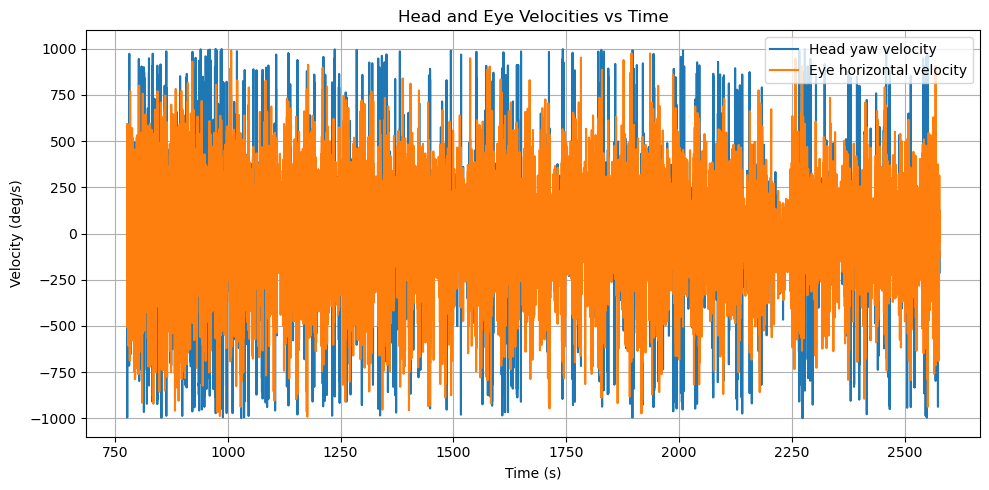

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1️⃣ Extract data ---
eye_time = data['eye_time'].squeeze()
eye_pos = data['eye_deg'][:, 0]  # horizontal eye position (deg)
eye_is_free = data['eye_isSac_free'].squeeze().astype(bool)  # logical mask

opti_time = data['opti_time'].squeeze()
head_yaw = data['opti_headrot_smo'][:, 0]  # yaw (deg)

# --- 2️⃣ Compute velocities (deg/s) ---
eye_hor_vel_full = np.gradient(eye_pos, eye_time)
head_yaw_vel = np.gradient(head_yaw, opti_time)

# --- 3️⃣ Interpolate head velocity to eye timestamps ---
interp_head_yaw_vel = interp1d(
    opti_time, head_yaw_vel,
    bounds_error=False, fill_value="extrapolate"
)
head_yaw_vel_resampled_full = interp_head_yaw_vel(eye_time)

# --- 4️⃣ Get time window from data['t'] 4th column ---
t_start, t_end = data['t'][3, 0], data['t'][3, 1] 
print(f"Using time window: {t_start:.3f} – {t_end:.3f} s")

# Create a mask for the time window
time_mask = (eye_time >= t_start) & (eye_time <= t_end)

free_mask = (
    np.isfinite(eye_hor_vel_full)
    & np.isfinite(head_yaw_vel_resampled_full)
    & (np.abs(head_yaw_vel_resampled_full) <= 1000)
    & (np.abs(eye_hor_vel_full) <= 1000)
    & time_mask
)

# Apply mask
eye_time_sel = eye_time[free_mask]
eye_hor_vel_sel = eye_hor_vel_full[free_mask]
head_yaw_vel_sel = head_yaw_vel_resampled_full[free_mask]

print(f"Samples in window: {np.sum(free_mask)}")

# --- 6️⃣ Plot time series ---
plt.figure(figsize=(10, 5))
plt.plot(eye_time_sel, head_yaw_vel_sel, label='Head yaw velocity', color='tab:blue')
plt.plot(eye_time_sel, eye_hor_vel_sel, label='Eye horizontal velocity', color='tab:orange')

plt.xlabel('Time (s)')
plt.ylabel('Velocity (deg/s)')
plt.title('Head and Eye Velocities vs Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




Random 10-s window: 1563.127 – 1573.127 s
Correlation results:
Fixation: r = -0.510
Gaze shift: r = -0.219


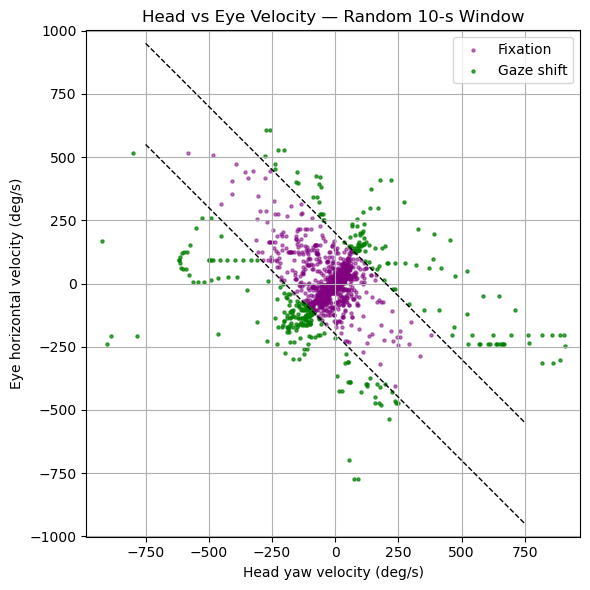

In [8]:
import random
from scipy.stats import pearsonr

# --- 🟣 Randomly select a 10-second window within selected time range ---
window_duration = 10.0
valid_start = t_start
valid_end = t_end - window_duration

# Random start time
rand_start = random.uniform(valid_start, valid_end)
rand_end = rand_start + window_duration

print(f"Random 10-s window: {rand_start:.3f} – {rand_end:.3f} s")

# Create mask for that 10-s interval
rand_mask = (eye_time_sel >= rand_start) & (eye_time_sel <= rand_end)
# --- 🔶 Detect gaze shifts & fixations within random 10-s window ---
gaze_vel_rand = head_yaw_vel_sel[rand_mask] + eye_hor_vel_sel[rand_mask]
is_shift = np.abs(gaze_vel_rand) > 200   # gaze shift threshold
is_fix = ~is_shift                       # fixation (complement)



# --- 🧮 Extract velocity pairs for each condition ---
head_fix = head_yaw_vel_sel[rand_mask][is_fix]
eye_fix = eye_hor_vel_sel[rand_mask][is_fix]
head_shift = head_yaw_vel_sel[rand_mask][is_shift]
eye_shift = eye_hor_vel_sel[rand_mask][is_shift]

# --- 📈 Calculate Pearson correlation (r) and p-value ---
r_fix, p_fix = pearsonr(head_fix, eye_fix)
r_shift, p_shift = pearsonr(head_shift, eye_shift)

# --- 🧾 Print results ---
print("Correlation results:")
print(f"Fixation: r = {r_fix:.3f}")
print(f"Gaze shift: r = {r_shift:.3f}")


# --- 🔷 Scatter plot: head vs eye velocity, colored by type ---
plt.figure(figsize=(6, 6))
plt.scatter(
    head_yaw_vel_sel[rand_mask][is_fix],
    eye_hor_vel_sel[rand_mask][is_fix],
    s=5, color='purple', alpha=0.5, label='Fixation'
)
plt.scatter(
    head_yaw_vel_sel[rand_mask][is_shift],
    eye_hor_vel_sel[rand_mask][is_shift],
    s=5, color='green', alpha=0.7, label='Gaze shift'
)

# Reference lines (±1 slope)
x = np.linspace(-750, 750, 200)
plt.plot(x, -200-x, 'k--', linewidth=1)
plt.plot(x, 200-x, 'k--', linewidth=1)

plt.xlabel('Head yaw velocity (deg/s)')
plt.ylabel('Eye horizontal velocity (deg/s)')
plt.title('Head vs Eye Velocity — Random 10-s Window')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()


=== FIXATION ===
Head mean=-9.33, std=73.17, var=5353.60
Eye  mean=9.82, std=75.03, var=5630.15
|Head| mean=42.15, std=60.53, var=3663.83
|Eye|  mean=44.48, std=61.22, var=3747.89
Regression slope (eye~head): -0.523, r=-0.510, p=6.955e-111

=== GAZE SHIFT ===
Detected 19 gaze-shift events.
Head mean=-23.15, std=326.04, var=106304.33
Eye  mean=-49.44, std=228.05, var=52005.44
|Head| mean=246.53, std=214.62, var=46061.93
|Eye|  mean=192.47, std=131.93, var=17404.91
Mean duration per event = 15.1 samples


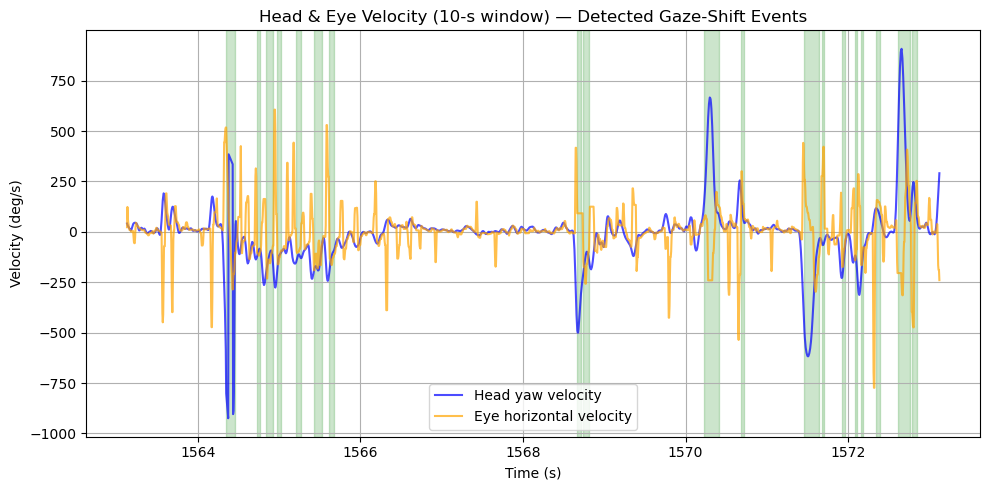

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ==============================================================
# 🟣 FIXATION STATS
# ==============================================================
is_shift = np.abs(gaze_vel_rand) > 200   # gaze shift threshold
is_fix = ~is_shift                       # fixation (complement)
head_fix = head_yaw_vel_sel[rand_mask][is_fix]
eye_fix = eye_hor_vel_sel[rand_mask][is_fix]

mean_head_fix = np.mean(head_fix)
std_head_fix = np.std(head_fix)
var_head_fix = np.var(head_fix)

mean_eye_fix = np.mean(eye_fix)
std_eye_fix = np.std(eye_fix)
var_eye_fix = np.var(eye_fix)

# Absolute values
abs_mean_head_fix = np.mean(np.abs(head_fix))
abs_std_head_fix = np.std(np.abs(head_fix))
abs_var_head_fix = np.var(np.abs(head_fix))

abs_mean_eye_fix = np.mean(np.abs(eye_fix))
abs_std_eye_fix = np.std(np.abs(eye_fix))
abs_var_eye_fix = np.var(np.abs(eye_fix))

# Regression
slope_fix, intercept_fix, r_fix, p_fix, stderr_fix = linregress(head_fix, eye_fix)

print("=== FIXATION ===")
print(f"Head mean={mean_head_fix:.2f}, std={std_head_fix:.2f}, var={var_head_fix:.2f}")
print(f"Eye  mean={mean_eye_fix:.2f}, std={std_eye_fix:.2f}, var={var_eye_fix:.2f}")
print(f"|Head| mean={abs_mean_head_fix:.2f}, std={abs_std_head_fix:.2f}, var={abs_var_head_fix:.2f}")
print(f"|Eye|  mean={abs_mean_eye_fix:.2f}, std={abs_std_eye_fix:.2f}, var={abs_var_eye_fix:.2f}")
print(f"Regression slope (eye~head): {slope_fix:.3f}, r={r_fix:.3f}, p={p_fix:.3e}")

# ==============================================================
# 🟢 GAZE SHIFT STATS
# ==============================================================

head_shift = head_yaw_vel_sel[rand_mask][is_shift]
eye_shift = eye_hor_vel_sel[rand_mask][is_shift]

mean_head_shift = np.mean(head_shift)
std_head_shift = np.std(head_shift)
var_head_shift = np.var(head_shift)

mean_eye_shift = np.mean(eye_shift)
std_eye_shift = np.std(eye_shift)
var_eye_shift = np.var(eye_shift)

# Absolute values
abs_mean_head_shift = np.mean(np.abs(head_shift))
abs_std_head_shift = np.std(np.abs(head_shift))
abs_var_head_shift = np.var(np.abs(head_shift))

abs_mean_eye_shift = np.mean(np.abs(eye_shift))
abs_std_eye_shift = np.std(np.abs(eye_shift))
abs_var_eye_shift = np.var(np.abs(eye_shift))



# ==============================================================
# 🔷 PLOT TIME-SERIES (20-s WINDOW) — only detected events
# ==============================================================

time_rand = eye_time_sel[rand_mask]
head_rand = head_yaw_vel_sel[rand_mask]
eye_rand = eye_hor_vel_sel[rand_mask]

# --- Detect gaze-shift events (≥20 samples, ≤1 dip allowed) ---
is_shift_seq = is_shift.astype(int)
events = []
count = 0
below_count = 0
start_idx = None

for i, val in enumerate(is_shift_seq):
    if val == 1:
        if start_idx is None:
            start_idx = i
        count += 1
    else:
        if count > 0 and below_count < 1   :
            below_count += 1  # allow one dip
        else:
            if count >= 6 and start_idx is not None:
                end_idx = i
                events.append((start_idx, end_idx))
            count = 0
            below_count = 0
            start_idx = None

# handle end-of-sequence case
if count >= 20 and start_idx is not None:
    events.append((start_idx, len(is_shift_seq)))
num_shifts = len(events)
mean_duration_shift = np.mean([end - start for start, end in events]) if num_shifts > 0 else np.nan

print("\n=== GAZE SHIFT ===")
print(f"Detected {len(events)} gaze-shift events.")
print(f"Head mean={mean_head_shift:.2f}, std={std_head_shift:.2f}, var={var_head_shift:.2f}")
print(f"Eye  mean={mean_eye_shift:.2f}, std={std_eye_shift:.2f}, var={var_eye_shift:.2f}")
print(f"|Head| mean={abs_mean_head_shift:.2f}, std={abs_std_head_shift:.2f}, var={abs_var_head_shift:.2f}")
print(f"|Eye|  mean={abs_mean_eye_shift:.2f}, std={abs_std_eye_shift:.2f}, var={abs_var_eye_shift:.2f}")
print(f"Mean duration per event = {mean_duration_shift:.1f} samples")




# --- Plot full 10-s traces ---
plt.figure(figsize=(10, 5))
plt.plot(time_rand, head_rand, label='Head yaw velocity', color='blue', alpha=0.7)
plt.plot(time_rand, eye_rand, label='Eye horizontal velocity', color='orange', alpha=0.7)

# --- Highlight only detected events ---
for start, end in events:
    plt.axvspan(time_rand[start], time_rand[end-1], color='green', alpha=0.2)

plt.xlabel("Time (s)")
plt.ylabel("Velocity (deg/s)")
plt.title("Head & Eye Velocity (10-s window) — Detected Gaze-Shift Events")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




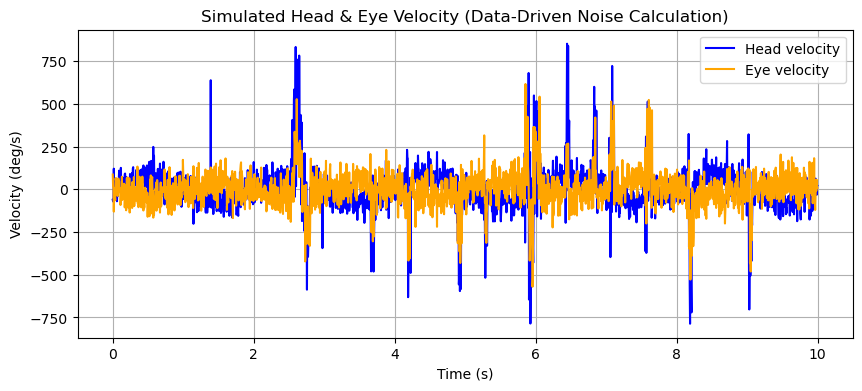

Fixation (simulated): r=-0.579, p=1.313e-179
Gaze-shift (simulated): r=0.533, p=2.132e-19


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- 1. Time vector ---
fs = 200          # Hz
dt = 1/fs
T = 10.0
time = np.arange(0, T, dt)
n_samples = len(time)

# --- 2. Fixation baseline ---
A_head_fix = (np.pi / 2) * abs_mean_head_fix
A_eye_fix  = (np.pi / 2) * abs_mean_eye_fix
r = slope_fix
f_fix = 0.5  # Hz

# --- Noise std calculation based on variance ---
# Variance of the sine function: var_sin = (A^2)/2 for full sine over one period
var_sin_head_fix = (A_head_fix**2) / 2
var_sin_eye_fix  = (A_eye_fix**2) / 2

# Noise std = sqrt(var_data - var_sin)
noise_std_head_fix = np.sqrt(max(var_head_fix - var_sin_head_fix, 0))
noise_std_eye_fix  = np.sqrt(max(var_eye_fix  - var_sin_eye_fix, 0))

# Generate fixation baseline
Vhead_fix = A_head_fix * np.sin(2*np.pi*f_fix*time) + np.random.normal(0, noise_std_head_fix, n_samples)
Veye_fix  = r * Vhead_fix + np.random.normal(0, noise_std_eye_fix, n_samples)

# --- 3. Gaze-shift events ---
n_events = len(events)  # number of events to simulate
durations = np.array([end-start for start, end in events]) * dt
std_duration_shift = np.std(durations)
mean_duration_shift = np.mean(durations)

# Amplitude for gaze-shift pulses
A_head_peak = (np.pi / 2) * abs_mean_head_shift - A_head_fix
A_eye_peak  = (np.pi / 2) * abs_mean_eye_shift  - A_eye_fix

# Variance of sine for shift
var_sin_head_shift = (A_head_peak**2) / 2
var_sin_eye_shift  = (A_eye_peak**2) / 2

# Noise std for gaze-shift
noise_std_head_event = np.sqrt(max(var_head_shift - var_head_fix - var_sin_head_shift, 0))
noise_std_eye_event  = np.sqrt(max(var_eye_shift  - var_eye_fix  - var_sin_eye_shift, 0))

Vhead_event = np.zeros_like(time)
Veye_event  = np.zeros_like(time)

for _ in range(n_events):
    # Random start time
    D_head = max(np.random.normal(mean_duration_shift, std_duration_shift), dt)
    D_eye  = D_head
    t0 = np.random.uniform(0, T-D_head)
    
    # Random sign
    pulse_sign = np.random.choice([-1, 1])
    
    idx_start = int(t0/dt)
    idx_end_head = int(min((t0+D_head)/dt, n_samples))
    idx_end_eye  = int(min((t0+D_eye)/dt, n_samples))
    
    t_head = time[idx_start:idx_end_head] - t0
    t_eye  = time[idx_start:idx_end_eye] - t0
    
    # Add pulse with noise
    Vhead_event[idx_start:idx_end_head] += pulse_sign * (
        A_head_peak * np.sin(np.pi * t_head / D_head) +
        np.random.normal(0, noise_std_head_event, len(t_head))
    )
    Veye_event[idx_start:idx_end_eye] += pulse_sign * (
        A_eye_peak * np.sin(np.pi * t_eye / D_eye) +
        np.random.normal(0, noise_std_eye_event, len(t_eye))
    )

# --- 4. Combine baseline + events ---
Vhead_real = Vhead_fix + Vhead_event
Veye_real  = Veye_fix + Veye_event

# --- 5. Plot ---
plt.figure(figsize=(10,4))
plt.plot(time, Vhead_real, label='Head velocity', color='blue')
plt.plot(time, Veye_real,  label='Eye velocity', color='orange')
plt.xlabel("Time (s)")
plt.ylabel("Velocity (deg/s)")
plt.title("Simulated Head & Eye Velocity (Data-Driven Noise Calculation)")
plt.grid(True)
plt.legend()
plt.show()

# --- 6. Compute correlations ---
r_fix_sim, p_fix_sim = pearsonr(Vhead_fix, Veye_fix)
r_shift_sim, p_shift_sim = pearsonr(Vhead_event[Vhead_event!=0], Veye_event[Veye_event!=0])

print(f"Fixation (simulated): r={r_fix_sim:.3f}, p={p_fix_sim:.3e}")
print(f"Gaze-shift (simulated): r={r_shift_sim:.3f}, p={p_shift_sim:.3e}")




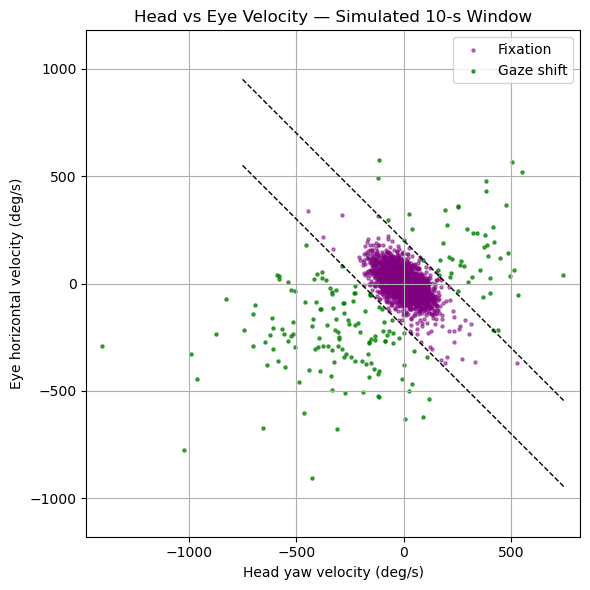

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Detect gaze shifts ---
# Threshold method: gaze shift if |Vhead + Veye| > 200 deg/s
gaze_vel = Vhead_real + Veye_real
is_shift = np.abs(gaze_vel) > 200
is_fix   = ~is_shift

# --- 2. Scatter plot (like your reference) ---
plt.figure(figsize=(6,6))
plt.scatter(
    Vhead_real[is_fix],
    Veye_real[is_fix],
    s=5, color='purple', alpha=0.5, label='Fixation'
)
plt.scatter(
    Vhead_real[is_shift],
    Veye_real[is_shift],
    s=5, color='green', alpha=0.7, label='Gaze shift'
)

# Reference lines (±1 slope)
x = np.linspace(-750, 750, 200)
plt.plot(x, -200-x, 'k--', linewidth=1)
plt.plot(x, 200-x, 'k--', linewidth=1)

plt.xlabel('Head yaw velocity (deg/s)')
plt.ylabel('Eye horizontal velocity (deg/s)')
plt.title('Head vs Eye Velocity — Simulated 10-s Window')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()



In [12]:
# Still some questions: highly positive relation betwwen eye and head velocity in gaze shift
# The data is not as smooth as raw data, if we use the smooth function, the correlation close to 1

# try to distinguish two pulse 

Sampling rate ≈ 200.0 Hz

Detected 14 eye-only events (Type 1)
Detected 19 combined gaze shifts (Type 2)

=== Type 1 (Eye-only small shift) ===
Events: 14
Head mean=10.82, std=114.16, var=13033.61
Eye  mean=-82.67, std=323.02, var=104341.83
|Head| mean=102.19, |Eye| mean=321.40
|Head| var=2707.44, |Eye| var=7878.95
Slope (eye~head)=-2.514, r=-0.888, p=1.746e-16
Duration mean=16.4 ms, std=4.8 ms, var=23.0

=== Type 2 (Combined large shift) ===
Events: 19
Head mean=-33.09, std=331.05, var=109592.08
Eye  mean=-36.75, std=198.45, var=39381.28
|Head| mean=255.00, |Eye| mean=164.53
|Head| var=45661.10, |Eye| var=13660.18
Slope (eye~head)=-0.134, r=-0.223, p=5.721e-05
Duration mean=84.2 ms, std=48.8 ms, var=2382.3


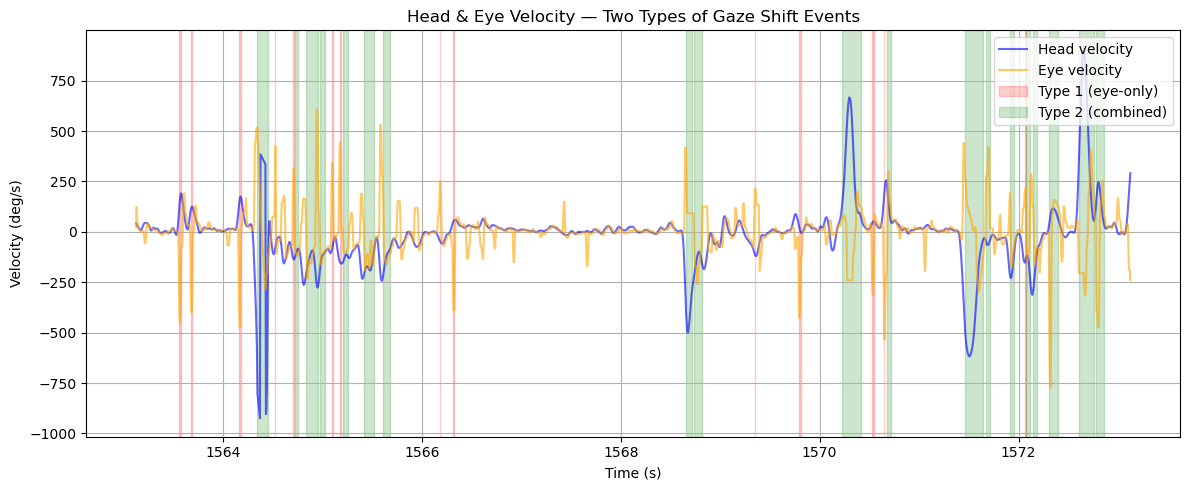

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ==============================================================
# 🔹 Basic variables
# ==============================================================
time = eye_time_sel[rand_mask]
Vhead = head_yaw_vel_sel[rand_mask]
Veye  = eye_hor_vel_sel[rand_mask]

n = len(time)
fs_est = 1 / np.median(np.diff(time))  # approximate sampling rate
print(f"Sampling rate ≈ {fs_est:.1f} Hz")

# ==============================================================
# 🔹 Event type detection
# ==============================================================

thr = 200  # deg/s

# --- Type 1: Eye-only shift ---
eye_only_mask = (np.abs(Veye) > thr) & (np.abs(Vhead) < thr)
# Mark continuous sequences ≥2 samples
type1_events = []
count, start = 0, None
for i, val in enumerate(eye_only_mask):
    if val:
        if start is None: start = i
        count += 1
    else:
        if count >= 2:
            type1_events.append((start, i))
        count, start = 0, None
if count >= 2 and start is not None:
    type1_events.append((start, len(eye_only_mask)))

# --- Type 2: Combined head+eye shift ---
combined_vel = np.abs(Vhead + Veye)
type2_mask = np.zeros_like(Vhead, dtype=bool)

# Check every 6-sample window
for i in range(n - 5):
    if np.sum(combined_vel[i:i+6] > thr) >= 5:
        type2_mask[i:i+6] = True

# Extract continuous Type 2 sequences
type2_events = []
count, start = 0, None
for i, val in enumerate(type2_mask):
    if val:
        if start is None: start = i
        count += 1
    else:
        if count >= 6:
            type2_events.append((start, i))
        count, start = 0, None
if count >= 6 and start is not None:
    type2_events.append((start, len(type2_mask)))

# --- Remove overlaps (Type 2 takes precedence) ---
final_type1 = []
for start, end in type1_events:
    overlap = any([(s < end and e > start) for s, e in type2_events])
    if not overlap:
        final_type1.append((start, end))

print(f"\nDetected {len(final_type1)} eye-only events (Type 1)")
print(f"Detected {len(type2_events)} combined gaze shifts (Type 2)")

# ==============================================================
# 🔹 Compute statistics for each event type
# ==============================================================

def event_stats(Vhead, Veye, events, fs):
    """Compute mean/std/var, absolute stats, and duration stats for events."""
    all_head, all_eye, durations = [], [], []
    for s, e in events:
        all_head.extend(Vhead[s:e])
        all_eye.extend(Veye[s:e])
        durations.append((e - s) / fs)  # seconds

    if len(all_head) == 0:
        return None

    all_head, all_eye = np.array(all_head), np.array(all_eye)
    stats = {
        'mean_head': np.mean(all_head),
        'std_head':  np.std(all_head),
        'var_head':  np.var(all_head),
        'abs_mean_head': np.mean(np.abs(all_head)),
        'abs_std_head': np.std(np.abs(all_head)),
        'abs_var_head': np.var(np.abs(all_head)),
        'mean_eye': np.mean(all_eye),
        'std_eye':  np.std(all_eye),
        'var_eye':  np.var(all_eye),
        'abs_mean_eye': np.mean(np.abs(all_eye)),
        'abs_std_eye': np.std(np.abs(all_eye)),
        'abs_var_eye': np.var(np.abs(all_eye)),
        'dur_mean': np.mean(durations) if durations else np.nan,
        'dur_std':  np.std(durations) if durations else np.nan,
        'dur_var':  np.var(durations) if durations else np.nan,
        'n_events': len(durations)
    }

    slope, intercept, r, p, stderr = linregress(all_head, all_eye)
    stats.update({'slope': slope, 'r': r, 'p': p})
    return stats

stats_type1 = event_stats(Vhead, Veye, final_type1, fs_est)
stats_type2 = event_stats(Vhead, Veye, type2_events, fs_est)



# ==============================================================
# 🔹 Print results
# ==============================================================
def print_stats(label, s):
    if s is None:
        print(f"\n=== {label}: no events ===")
        return
    print(f"\n=== {label} ===")
    print(f"Events: {s['n_events']}")
    print(f"Head mean={s['mean_head']:.2f}, std={s['std_head']:.2f}, var={s['var_head']:.2f}")
    print(f"Eye  mean={s['mean_eye']:.2f}, std={s['std_eye']:.2f}, var={s['var_eye']:.2f}")
    print(f"|Head| mean={s['abs_mean_head']:.2f}, |Eye| mean={s['abs_mean_eye']:.2f}")
    print(f"|Head| var={s['abs_var_head']:.2f}, |Eye| var={s['abs_var_eye']:.2f}")
    print(f"Slope (eye~head)={s['slope']:.3f}, r={s['r']:.3f}, p={s['p']:.3e}")
    print(f"Duration mean={s['dur_mean']*1000:.1f} ms, std={s['dur_std']*1000:.1f} ms, var={s['dur_var']*1e6:.1f}")

print_stats("Type 1 (Eye-only small shift)", stats_type1)
print_stats("Type 2 (Combined large shift)", stats_type2)

# ==============================================================
# 🔹 Plot results
# ==============================================================

plt.figure(figsize=(12, 5))
plt.plot(time, Vhead, label='Head velocity', color='blue', alpha=0.6)
plt.plot(time, Veye,  label='Eye velocity',  color='orange', alpha=0.6)

# --- Highlight event regions ---
label1, label2 = True, True  # add label only for the first occurrence

for s, e in final_type1:
    plt.axvspan(time[s], time[e-1], color='red', alpha=0.2,
                label='Type 1 (eye-only)' if label1 else None)
    label1 = False

for s, e in type2_events:
    plt.axvspan(time[s], time[e-1], color='green', alpha=0.2,
                label='Type 2 (combined)' if label2 else None)
    label2 = False

plt.xlabel("Time (s)")
plt.ylabel("Velocity (deg/s)")
plt.title("Head & Eye Velocity — Two Types of Gaze Shift Events")
plt.legend(loc='upper right', frameon=True)
plt.grid(True)
plt.tight_layout()
plt.show()



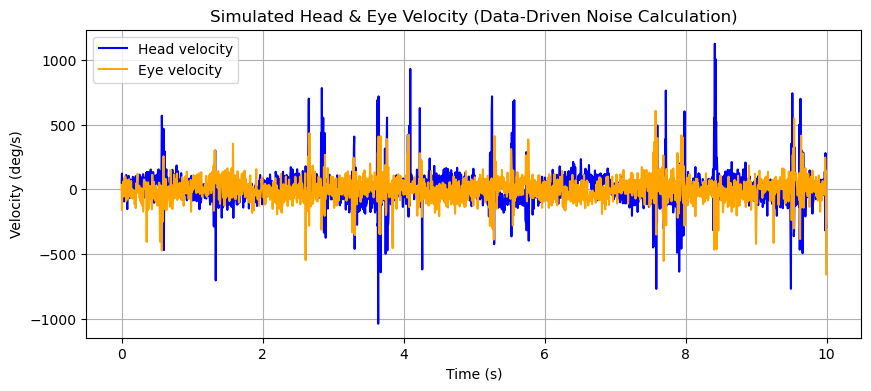

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- 1. Time vector ---
fs = 200          # Hz
dt = 1/fs
T = 10.0
time = np.arange(0, T, dt)
n_samples = len(time)

# --- 2. Fixation baseline ---
A_head_fix = (np.pi / 2) * abs_mean_head_fix
A_eye_fix  = (np.pi / 2) * abs_mean_eye_fix
r = slope_fix
f_fix = 0.5  # Hz

# --- Noise std calculation based on variance ---
# Variance of the sine function: var_sin = (A^2)/2 for full sine over one period
var_sin_head_fix = (A_head_fix**2) / 2
var_sin_eye_fix  = (A_eye_fix**2) / 2

# Noise std = sqrt(var_data - var_sin)
noise_std_head_fix = np.sqrt(max(var_head_fix - var_sin_head_fix, 0))
noise_std_eye_fix  = np.sqrt(max(var_eye_fix  - var_sin_eye_fix, 0))

# Generate fixation baseline
Vhead_fix = A_head_fix * np.sin(2*np.pi*f_fix*time) + np.random.normal(0, noise_std_head_fix, n_samples)
Veye_fix  = r * Vhead_fix + np.random.normal(0, noise_std_eye_fix, n_samples)

# ==============================================================
# 🔹 Create event1 and event2 from stats_type1 and stats_type2
# ==============================================================
event1 = []  # eye-only events
event2 = []  # combined head+eye events

# --- Type 1: Eye-only events ---
n_events1 = stats_type1['n_events'] if stats_type1 is not None else 0
mean_dur1 = stats_type1['dur_mean'] if stats_type1 is not None else 0
std_dur1  = stats_type1['dur_std']  if stats_type1 is not None else 0

for _ in range(n_events1):
    start_idx = np.random.randint(0, n_samples)
    duration_samples = max(int(np.random.normal(mean_dur1*fs_est, std_dur1*fs_est)), 2)
    end_idx = min(start_idx + duration_samples, n_samples)
    event1.append((start_idx, end_idx))

# --- Type 2: Combined events ---
n_events2 = stats_type2['n_events'] if stats_type2 is not None else 0
mean_dur2 = stats_type2['dur_mean'] if stats_type2 is not None else 0
std_dur2  = stats_type2['dur_std']  if stats_type2 is not None else 0

for _ in range(n_events2):
    start_idx = np.random.randint(0, n_samples)
    duration_samples = max(int(np.random.normal(mean_dur2*fs_est, std_dur2*fs_est)), 2)
    end_idx = min(start_idx + duration_samples, n_samples)
    event2.append((start_idx, end_idx))

# --- Ensure non-overlap ---
occupied = np.zeros(n_samples, dtype=bool)
final_event1 = []
for s,e in event1:
    if not np.any(occupied[s:e]):
        final_event1.append((s,e))
        occupied[s:e] = True

final_event2 = []
for s,e in event2:
    if not np.any(occupied[s:e]):
        final_event2.append((s,e))
        occupied[s:e] = True

# ==============================================================
# 🔹 Generate Vhead_event and Veye_event from these events
# ==============================================================
Vhead_event = np.zeros_like(time)
Veye_event  = np.zeros_like(time)

# --- Type 1 (eye-only) ---
for s, e in final_event1:
    D_eye = (e - s) * dt
    N = e - s  # number of points in this pulse
    t_eye = np.arange(N) * dt  # time relative to pulse start

    # Peak amplitude based on stats
    A_eye_peak1 = (np.pi/2)*stats_type1['abs_mean_eye'] - mean_eye_fix  # use variance-based amplitude

    #Compute sine pulse over actual points
    pulse_eye = A_eye_peak1 * np.sin(np.pi * t_eye / D_eye)
    
    # Absolute variance (variance of |pulse|)
    var_sin_eye1 = np.var(np.abs(pulse_eye))  

    # Noise std to match overall variance
    noise_std_eye1 = np.sqrt(max(stats_type1['abs_var_eye'] - var_eye_fix - var_sin_eye1, 0))
    
    # Random sign for pulse
    pulse_sign = np.random.choice([-1, 1])
    Veye_event[s:e] += pulse_sign * (pulse_eye + np.random.normal(0, noise_std_eye1, N))


# --- Type 2 (combined head+eye) with different sine durations ---
for s, e in final_event2:
    D_event = (e - s) * dt
    N = e - s
    t = np.arange(N) * dt  # local time from event start.  # Peak amplitudes (keep your data-driven stats; cap eye ~400 deg/s)
    A_head_peak2 = (np.pi/2) * stats_type2['mean_head'] - mean_head_fix
    A_eye_peak2  = (np.pi/2) * stats_type2['mean_eye']  - mean_eye_fix
    A_eye_peak2  = np.sign(A_eye_peak2) * min(abs(A_eye_peak2), 400.0)

    # ---- Timing control (half-sines): eye earlier, head later ----
    D_eye  = 0.60 * D_event   # shorter → earlier peak (at D_eye/2)
    D_head = 1.10 * D_event   # longer  → later, broader pulse
    delay_head = 0.02 * D_event  # push head onset to the right

    # Local times for each component
    t_eye  = t
    t_head = t - delay_head

    # Half-sine windows: only defined on [0, D_*]
    eye_win  = (t_eye  >= 0) & (t_eye  <= D_eye)
    head_win = (t_head >= 0) & (t_head <= D_head)

    eye_core  = np.zeros_like(t)
    head_core = np.zeros_like(t)
    eye_core[eye_win]   = A_eye_peak2  * np.sin(np.pi * t_eye[eye_win]  / D_eye)
    head_core[head_win] = A_head_peak2 * np.sin(np.pi * t_head[head_win] / D_head)

    # ---- VOR re-engagement: subtract a fraction of the head after its peak ----
    t_head_peak = delay_head + 0.5 * D_head
    vor_mask = (t >= t_head_peak).astype(float)
    vor_gain = r
    eye_comp = -vor_gain * head_core * vor_mask

    pulse_head = head_core
    pulse_eye  = eye_core + eye_comp

    # Variance-matching noise (same idea as yours)
    var_head_core = np.var(pulse_head)
    var_eye_core  = np.var(pulse_eye)
    noise_std_head2 = np.sqrt(max(stats_type2['var_head'] - var_head_fix - var_head_core, 0))
    noise_std_eye2  = np.sqrt(max(stats_type2['var_eye']  - var_eye_fix  - var_eye_core,  0))

    # Random direction sign
    pulse_sign = np.random.choice([-1, 1])

    Vhead_event[s:e] += pulse_sign * (pulse_head + np.random.normal(0, noise_std_head2, N))
    Veye_event[s:e]  += pulse_sign * (pulse_eye  + np.random.normal(0, noise_std_eye2,  N)) 



# --- 4. Combine baseline + events ---
Vhead_real = Vhead_fix + Vhead_event
Veye_real  = Veye_fix + Veye_event

# --- 5. Plot ---
plt.figure(figsize=(10,4))
plt.plot(time, Vhead_real, label='Head velocity', color='blue')
plt.plot(time, Veye_real,  label='Eye velocity', color='orange')
plt.xlabel("Time (s)")
plt.ylabel("Velocity (deg/s)")
plt.title("Simulated Head & Eye Velocity (Data-Driven Noise Calculation)")
plt.grid(True)
plt.legend()
plt.show()

# Find indices where either head or eye has a non-zero event
shift_idx = np.where((Vhead_event != 0) | (Veye_event != 0))[0]

# Extract corresponding values
Vhead_shift = Vhead_event[shift_idx]
Veye_shift  = Veye_event[shift_idx]

# Compute correlation
r_shift_sim, p_shift_sim = pearsonr(Vhead_shift, Veye_shift)


In [69]:
## Still need show the VOR of event2 and different Duration of head and eye according to figure 6D

In [52]:
Vhead_real

array([-60.43972666,  44.67780379,  56.19841794, ...,  42.47580678,
        78.75507497,   0.17674663])

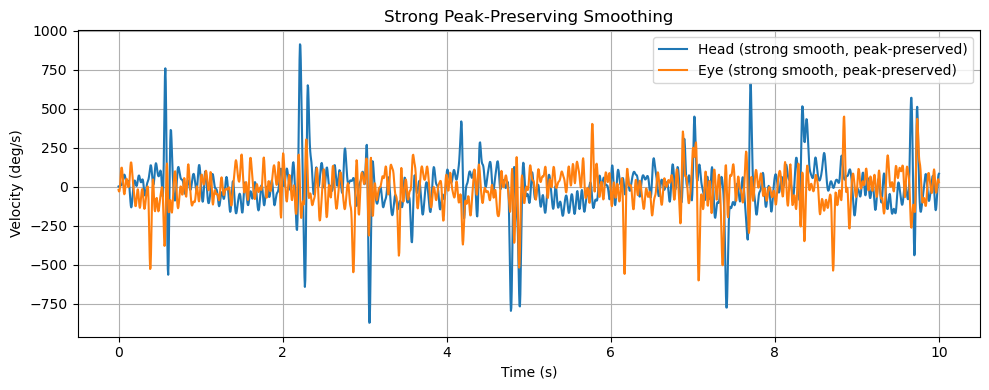

In [55]:
from scipy.signal import butter, filtfilt, medfilt, find_peaks
import numpy as np

def smooth_peak_preserve(x, fs, cutoff_hz=10, median_ms=7, peak_prom=50, peak_dist_ms=40, restore_sigma_ms=12):
    """
    Strong smoothing that preserves exact raw peak heights.
    x: 1D array
    fs: sampling rate (Hz)
    cutoff_hz: low-pass cutoff for strong smoothing
    median_ms: median filter window (ms), odd length enforced
    peak_prom: minimum prominence (same units as x) for peaks
    peak_dist_ms: minimum distance between peaks
    restore_sigma_ms: width of small Gaussian used to restore peak height
    """
    # --- 1) Median filter (small, odd window)
    k = max(3, int(round(median_ms * fs / 1000)))
    if k % 2 == 0: k += 1
    x_med = medfilt(x, kernel_size=k)

    # --- 2) Strong low-pass, zero-phase
    # 4th order Butterworth; adjust cutoff_hz to taste (lower = smoother)
    b, a = butter(4, cutoff_hz, btype='low', fs=fs)
    x_lp = filtfilt(b, a, x_med)

    # --- 3) Peak detect on RAW signal, then restore peak heights
    # detect positive and negative peaks separately
    min_dist = max(1, int(round(peak_dist_ms * fs / 1000)))
    pos_idx, _ = find_peaks(x, prominence=peak_prom, distance=min_dist)
    neg_idx, _ = find_peaks(-x, prominence=peak_prom, distance=min_dist)
    peak_idx = np.sort(np.concatenate([pos_idx, neg_idx]))

    # small Gaussian bump centered at each peak to match raw height
    sigma = max(1e-6, restore_sigma_ms / 1000.0)  # seconds
    t = np.arange(len(x)) / fs
    x_out = x_lp.copy()
    for i in peak_idx:
        # difference at the peak
        delta = x[i] - x_out[i]
        if delta == 0:
            continue
        # add a narrow Gaussian so the *value at the peak* equals raw
        g = np.exp(-0.5 * ((t - t[i]) / sigma)**2)
        # normalize so bump equals delta at the center sample
        # (g[i] is 1 by design, so this sets x_out[i] -> x[i])
        x_out += delta * g

    return x_out, peak_idx

# MUCH stronger smoothing + preserved peaks
Vhead_smooth, head_peaks = smooth_peak_preserve(
    Vhead_real, fs,
    cutoff_hz=6,        # ↓ lower cutoff → stronger smoothing
    median_ms=11,       # ↑ a touch more spike cleanup
    peak_prom=60,       # ↑ only restore salient peaks
    peak_dist_ms=50,    # ↑ prevent crowding
    restore_sigma_ms=16 # ↑ slightly wider peak restoration (less pointy)
)

Veye_smooth, eye_peaks = smooth_peak_preserve(
    Veye_real, fs,
    cutoff_hz=8,        # eye has faster dynamics; still strong smoothing
    median_ms=9,
    peak_prom=60,
    peak_dist_ms=40,
    restore_sigma_ms=14
)

# Plot the smoothed signals
plt.figure(figsize=(10,4))
plt.plot(time, Vhead_smooth, label='Head (strong smooth, peak-preserved)')
plt.plot(time, Veye_smooth,  label='Eye (strong smooth, peak-preserved)')
plt.xlabel("Time (s)"); plt.ylabel("Velocity (deg/s)")
plt.title("Strong Peak-Preserving Smoothing")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()



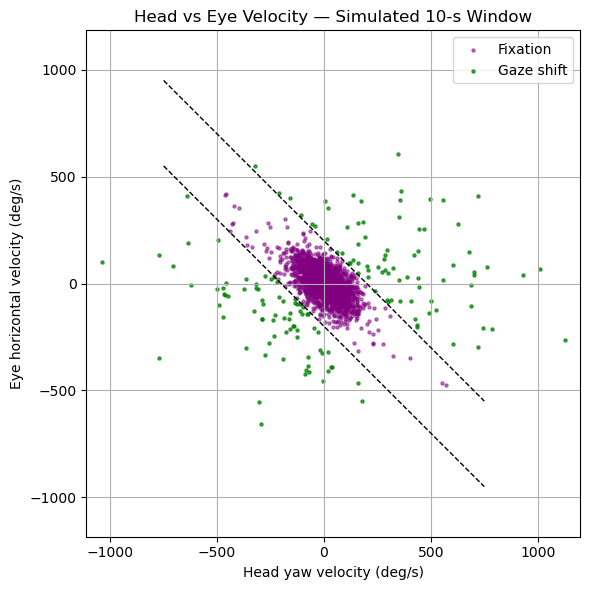

In [71]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Detect gaze shifts ---
# Threshold method: gaze shift if |Vhead + Veye| > 200 deg/s
gaze_vel = Vhead_real + Veye_real
is_shift = np.abs(gaze_vel) > 200
is_fix   = ~is_shift

# --- 2. Scatter plot (like your reference) ---
plt.figure(figsize=(6,6))
plt.scatter(
    Vhead_real[is_fix],
    Veye_real[is_fix],
    s=5, color='purple', alpha=0.5, label='Fixation'
)
plt.scatter(
    Vhead_real[is_shift],
    Veye_real[is_shift],
    s=5, color='green', alpha=0.7, label='Gaze shift'
)

# Reference lines (±1 slope)
x = np.linspace(-750, 750, 200)
plt.plot(x, -200-x, 'k--', linewidth=1)
plt.plot(x, 200-x, 'k--', linewidth=1)

plt.xlabel('Head yaw velocity (deg/s)')
plt.ylabel('Eye horizontal velocity (deg/s)')
plt.title('Head vs Eye Velocity — Simulated 10-s Window')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()



Sampling rate ≈ 199.9 Hz

Detected 7 eye-only events (Type 1)
Detected 23 combined gaze shifts (Type 2)

=== Type 1 (Eye-only small shift) ===
Events: 7
Head mean=10.04, std=82.50, var=6805.98
Eye  mean=-63.68, std=265.65, var=70571.62
|Head| mean=72.97, |Eye| mean=265.90
|Head| var=1581.96, |Eye| var=3922.36
Slope (eye~head)=-2.182, r=-0.678, p=3.811e-04
Duration mean=16.4 ms, std=6.9 ms, var=48.0

=== Type 2 (Combined large shift) ===
Events: 23
Head mean=28.24, std=358.69, var=128657.11
Eye  mean=-85.55, std=228.60, var=52259.86
|Head| mean=279.68, |Eye| mean=198.36
|Head| var=51233.11, |Eye| var=20234.50
Slope (eye~head)=0.094, r=0.147, p=1.339e-02
Duration mean=61.3 ms, std=22.0 ms, var=483.6


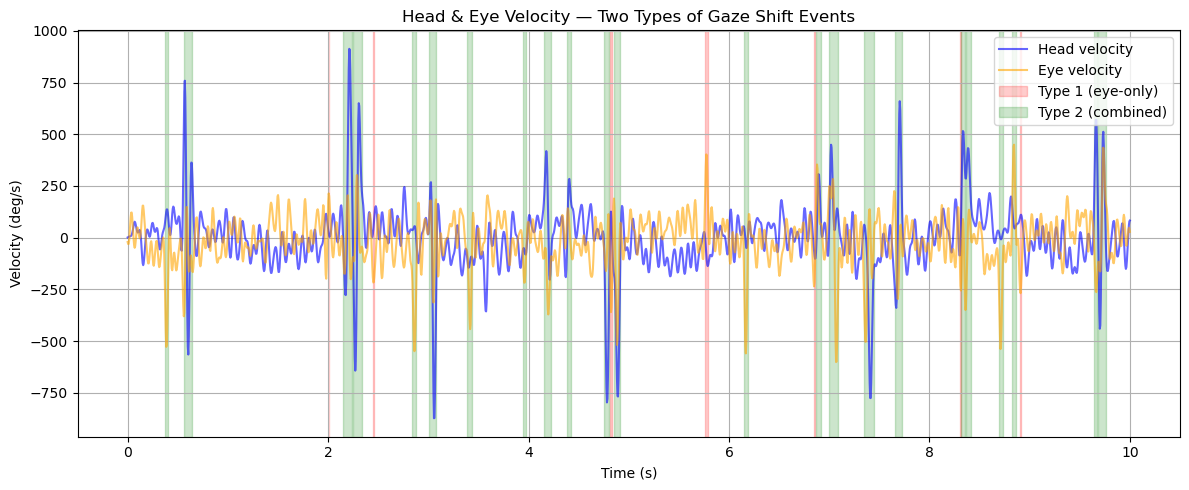

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ==============================================================
# 🔹 Basic variables
# ==============================================================
# total time duration (seconds)
T = 10  
# number of points
N = 2000  

# create time array from 0 to 10 s, inclusive
time = np.linspace(0, T, N)
Vhead = Vhead_smooth
Veye  = Veye_smooth

n = len(time)
fs_est = 1 / np.median(np.diff(time))  # approximate sampling rate
print(f"Sampling rate ≈ {fs_est:.1f} Hz")

# ==============================================================
# 🔹 Event type detection
# ==============================================================

thr = 200  # deg/s

# --- Type 1: Eye-only shift ---
eye_only_mask = (np.abs(Veye) > thr) & (np.abs(Vhead) < thr)
# Mark continuous sequences ≥2 samples
type1_events = []
count, start = 0, None
for i, val in enumerate(eye_only_mask):
    if val:
        if start is None: start = i
        count += 1
    else:
        if count >= 2:
            type1_events.append((start, i))
        count, start = 0, None
if count >= 2 and start is not None:
    type1_events.append((start, len(eye_only_mask)))

# --- Type 2: Combined head+eye shift ---
combined_vel = np.abs(Vhead + Veye)
type2_mask = np.zeros_like(Vhead, dtype=bool)

# Check every 6-sample window
for i in range(n - 5):
    if np.sum(combined_vel[i:i+6] > thr) >= 5:
        type2_mask[i:i+6] = True

# Extract continuous Type 2 sequences
type2_events = []
count, start = 0, None
for i, val in enumerate(type2_mask):
    if val:
        if start is None: start = i
        count += 1
    else:
        if count >= 6:
            type2_events.append((start, i))
        count, start = 0, None
if count >= 6 and start is not None:
    type2_events.append((start, len(type2_mask)))

# --- Remove overlaps (Type 2 takes precedence) ---
final_type1 = []
for start, end in type1_events:
    overlap = any([(s < end and e > start) for s, e in type2_events])
    if not overlap:
        final_type1.append((start, end))

print(f"\nDetected {len(final_type1)} eye-only events (Type 1)")
print(f"Detected {len(type2_events)} combined gaze shifts (Type 2)")

# ==============================================================
# 🔹 Compute statistics for each event type
# ==============================================================

def event_stats(Vhead, Veye, events, fs):
    """Compute mean/std/var, absolute stats, and duration stats for events."""
    all_head, all_eye, durations = [], [], []
    for s, e in events:
        all_head.extend(Vhead[s:e])
        all_eye.extend(Veye[s:e])
        durations.append((e - s) / fs)  # seconds

    if len(all_head) == 0:
        return None

    all_head, all_eye = np.array(all_head), np.array(all_eye)
    stats = {
        'mean_head': np.mean(all_head),
        'std_head':  np.std(all_head),
        'var_head':  np.var(all_head),
        'abs_mean_head': np.mean(np.abs(all_head)),
        'abs_std_head': np.std(np.abs(all_head)),
        'abs_var_head': np.var(np.abs(all_head)),
        'mean_eye': np.mean(all_eye),
        'std_eye':  np.std(all_eye),
        'var_eye':  np.var(all_eye),
        'abs_mean_eye': np.mean(np.abs(all_eye)),
        'abs_std_eye': np.std(np.abs(all_eye)),
        'abs_var_eye': np.var(np.abs(all_eye)),
        'dur_mean': np.mean(durations) if durations else np.nan,
        'dur_std':  np.std(durations) if durations else np.nan,
        'dur_var':  np.var(durations) if durations else np.nan,
        'n_events': len(durations)
    }

    slope, intercept, r, p, stderr = linregress(all_head, all_eye)
    stats.update({'slope': slope, 'r': r, 'p': p})
    return stats

stats_type1 = event_stats(Vhead, Veye, final_type1, fs_est)
stats_type2 = event_stats(Vhead, Veye, type2_events, fs_est)



# ==============================================================
# 🔹 Print results
# ==============================================================
def print_stats(label, s):
    if s is None:
        print(f"\n=== {label}: no events ===")
        return
    print(f"\n=== {label} ===")
    print(f"Events: {s['n_events']}")
    print(f"Head mean={s['mean_head']:.2f}, std={s['std_head']:.2f}, var={s['var_head']:.2f}")
    print(f"Eye  mean={s['mean_eye']:.2f}, std={s['std_eye']:.2f}, var={s['var_eye']:.2f}")
    print(f"|Head| mean={s['abs_mean_head']:.2f}, |Eye| mean={s['abs_mean_eye']:.2f}")
    print(f"|Head| var={s['abs_var_head']:.2f}, |Eye| var={s['abs_var_eye']:.2f}")
    print(f"Slope (eye~head)={s['slope']:.3f}, r={s['r']:.3f}, p={s['p']:.3e}")
    print(f"Duration mean={s['dur_mean']*1000:.1f} ms, std={s['dur_std']*1000:.1f} ms, var={s['dur_var']*1e6:.1f}")

print_stats("Type 1 (Eye-only small shift)", stats_type1)
print_stats("Type 2 (Combined large shift)", stats_type2)

# ==============================================================
# 🔹 Plot results
# ==============================================================

plt.figure(figsize=(12, 5))
plt.plot(time, Vhead, label='Head velocity', color='blue', alpha=0.6)
plt.plot(time, Veye,  label='Eye velocity',  color='orange', alpha=0.6)

# --- Highlight event regions ---
label1, label2 = True, True  # add label only for the first occurrence

for s, e in final_type1:
    plt.axvspan(time[s], time[e-1], color='red', alpha=0.2,
                label='Type 1 (eye-only)' if label1 else None)
    label1 = False

for s, e in type2_events:
    plt.axvspan(time[s], time[e-1], color='green', alpha=0.2,
                label='Type 2 (combined)' if label2 else None)
    label2 = False

plt.xlabel("Time (s)")
plt.ylabel("Velocity (deg/s)")
plt.title("Head & Eye Velocity — Two Types of Gaze Shift Events")
plt.legend(loc='upper right', frameon=True)
plt.grid(True)
plt.tight_layout()
plt.show()


Chosen Type 1 (eye-only) event: idx=(1152, 1158), duration=30.0 ms
Chosen Type 2 (combined) event: idx=(1468, 1489), duration=105.1 ms


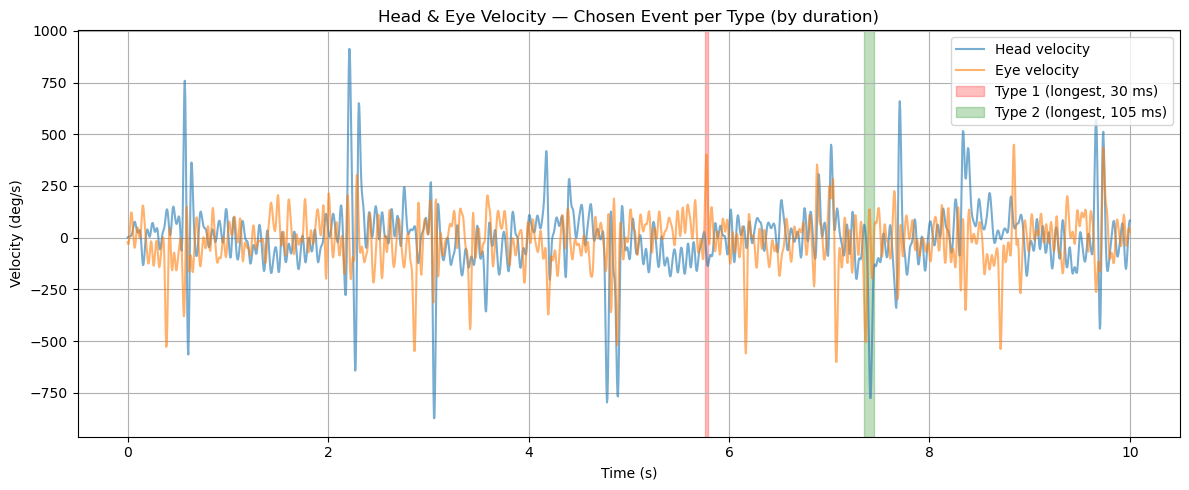

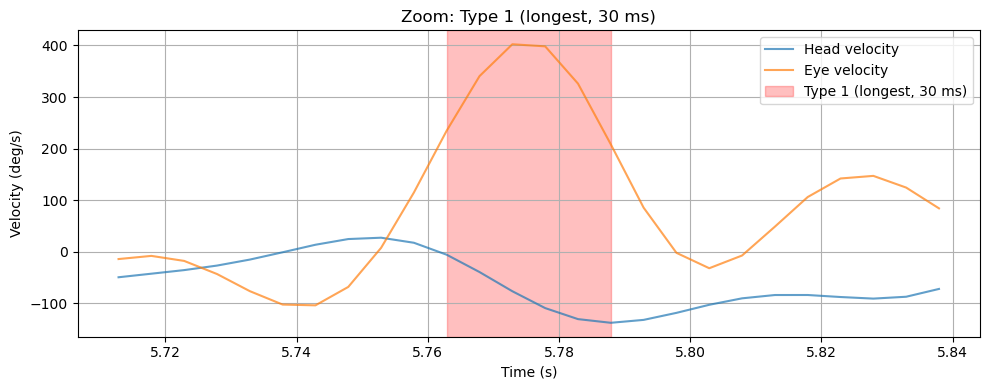

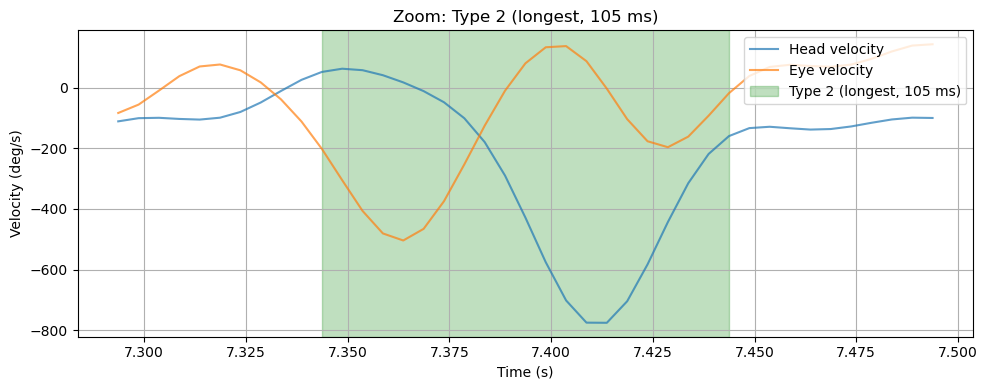

In [76]:
# ==============================================================
# 🔹 Choose ONE event per type (by longest duration) and plot
# ==============================================================

def choose_event_by_duration(events, fs):
    """Return (event_tuple, duration_sec) for the longest event, or (None, None) if empty."""
    if not events:
        return None, None
    durations = np.array([(e - s) / fs for s, e in events])
    idx = int(np.argmax(durations))
    return events[idx], float(durations[idx])

chosen_t1, dur_t1 = choose_event_by_duration(final_type1, fs_est)
chosen_t2, dur_t2 = choose_event_by_duration(type2_events, fs_est)

if chosen_t1:
    print(f"Chosen Type 1 (eye-only) event: idx=({chosen_t1[0]}, {chosen_t1[1]}), "
          f"duration={dur_t1*1000:.1f} ms")
else:
    print("No Type 1 (eye-only) event to plot.")

if chosen_t2:
    print(f"Chosen Type 2 (combined) event: idx=({chosen_t2[0]}, {chosen_t2[1]}), "
          f"duration={dur_t2*1000:.1f} ms")
else:
    print("No Type 2 (combined) event to plot.")

# ---------------- Full-span plot with only the chosen events highlighted ----------------
plt.figure(figsize=(12, 5))
plt.plot(time, Vhead, label='Head velocity', alpha=0.6)
plt.plot(time, Veye,  label='Eye velocity',  alpha=0.6)

if chosen_t1:
    s, e = chosen_t1
    plt.axvspan(time[s], time[e-1], alpha=0.25, color='red', label=f'Type 1 (longest, {dur_t1*1000:.0f} ms)')

if chosen_t2:
    s, e = chosen_t2
    plt.axvspan(time[s], time[e-1], alpha=0.25, color='green', label=f'Type 2 (longest, {dur_t2*1000:.0f} ms)')

plt.xlabel("Time (s)")
plt.ylabel("Velocity (deg/s)")
plt.title("Head & Eye Velocity — Chosen Event per Type (by duration)")
plt.legend(loc='upper right', frameon=True)
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------- Optional: zoomed plots around each chosen event ----------------
def zoom_plot(event, label, color):
    if not event: 
        return
    s, e = event
    # pad 20% of event length on both sides (min 10 samples)
    pad = max(int(0.2 * (e - s)), 10)
    a = max(s - pad, 0)
    b = min(e + pad, len(time)-1)

    plt.figure(figsize=(10, 4))
    plt.plot(time[a:b], Vhead[a:b], label='Head velocity', alpha=0.7)
    plt.plot(time[a:b], Veye[a:b],  label='Eye velocity',  alpha=0.7)
    plt.axvspan(time[s], time[e-1], alpha=0.25, color=color, label=label)
    plt.xlabel("Time (s)")
    plt.ylabel("Velocity (deg/s)")
    plt.title(f"Zoom: {label}")
    plt.legend(loc='upper right', frameon=True)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

zoom_plot(chosen_t1, f"Type 1 (longest, {dur_t1*1000:.0f} ms)" if chosen_t1 else "Type 1", "red")
zoom_plot(chosen_t2, f"Type 2 (longest, {dur_t2*1000:.0f} ms)" if chosen_t2 else "Type 2", "green")
